In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/customer_features.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/cohort_retention_matrix.csv
/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv


# Predicting Repeat Customers

## Objective

Customer retention was identified as the largest business opportunity in previous analyses.

This notebook develops machine learning models to predict whether a customer will become a repeat customer.

Business Question:

Can we identify customers likely to return and purchase again?

# Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import RandomForestClassifier

In [3]:
master = pd.read_csv("/kaggle/input/datasets/ananyasharma05/olist-marketplace-analytics-data/olist_master_clean.csv")

master.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,on_time_delivery,delivery_speed_group,negative_handoff_flag,customer_order_number,first_purchase_date,days_since_first_purchase,repeat_customer_flag,cohort_month,order_month_period,cohort_index
0,e22acc9c116caa3f2b7121bbb380d08e,1,372645c7439f9661fbbacfd129aa92ec,da8622b14eb17ae2831f4ac5b9dab84a,2018-05-15 11:11:18,129.90,12.00,fadbb3709178fc513abc1b2670aa1ad2,delivered,2018-05-10 10:56:27,...,True,fast,0,1,2018-05-10 10:56:27,0,0,2018-05,2018-05,1
1,3594e05a005ac4d06a72673270ef9ec9,1,5099f7000472b634fea8304448d20825,138dbe45fc62f1e244378131a6801526,2018-05-11 17:56:33,18.90,8.29,4cb282e167ae9234755102258dd52ee8,delivered,2018-05-07 11:11:27,...,True,fast,0,1,2018-05-07 11:11:27,0,0,2018-05,2018-05,1
2,b33ec3b699337181488304f362a6b734,1,64b488de448a5324c4134ea39c28a34b,3d871de0142ce09b7081e2b9d1733cb1,2017-03-15 21:05:03,69.00,17.22,9b3932a6253894a02c1df9d19004239f,delivered,2017-03-10 21:05:03,...,True,slow,0,1,2017-03-10 21:05:03,0,0,2017-03,2017-03,1
3,41272756ecddd9a9ed0180413cc22fb6,1,2345a354a6f2033609bbf62bf5be9ef6,ef506c96320abeedfb894c34db06f478,2017-10-18 21:49:17,25.99,17.63,914991f0c02ef0843c0e7010c819d642,delivered,2017-10-12 20:29:41,...,True,slow,0,1,2017-10-12 20:29:41,0,0,2017-10,2017-10,1
4,d957021f1127559cd947b62533f484f7,1,c72e18b3fe2739b8d24ebf3102450f37,70a12e78e608ac31179aea7f8422044b,2017-11-22 20:06:52,180.00,16.89,47227568b10f5f58a524a75507e6992c,delivered,2017-11-14 19:45:42,...,True,slow,0,1,2017-11-14 19:45:42,0,0,2017-11,2017-11,1


In [4]:
master["repeat_customer_flag"].value_counts()

repeat_customer_flag
0    105167
1      7483
Name: count, dtype: int64

In [5]:
master.shape

(112650, 48)

In [6]:
master.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'delivery_date_missing_flag',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'product_category_name_english',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'review_score',
 'review_creation_date',
 'review_answer_timestamp',
 'total_payment_value',
 'payment_installments_max',
 'payment_type_primary',
 'approval_latency_days',
 'carrier_handoff_days',
 'carrier_transit_days',
 'delivery_days',
 'delivery_promise_gap_days',
 'on_time_delivery',
 'delivery_speed_group',
 'negative_handoff_flag',
 'customer_order_number',
 'first_purchase_date',
 'days_si

# Feature Selection

Leakage variables were removed to ensure that the model predicts future customer behavior using information available at the time of purchase.

In [7]:
features = [
    "price",
    "freight_value",
    "total_payment_value",
    "payment_installments_max",
    "review_score",
    "approval_latency_days",
    "delivery_days",
    "on_time_delivery",
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm",
    "customer_state",
    "seller_state",
    "payment_type_primary",
    "product_category_name_english"
]

target = "repeat_customer_flag"

In [8]:
df = master[features + [target]].copy()

# Define X and y

In [9]:
X = df.drop(columns=[target])

y = df[target]

# Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.2,stratify=y,random_state=42)

In [11]:
y_train.value_counts(normalize=True)

repeat_customer_flag
0    0.933577
1    0.066423
Name: proportion, dtype: float64

In [12]:
categorical_features = X.select_dtypes(include="object").columns

numerical_features = X.select_dtypes(exclude="object").columns

In [13]:
preprocessor = ColumnTransformer(transformers=[

        ( "num",SimpleImputer(strategy="median"),numerical_features),

        ("cat",Pipeline([(
                    "imputer",SimpleImputer(strategy="most_frequent")),
                    ("encoder",OneHotEncoder(handle_unknown="ignore" ))
        ]),categorical_features
        )]
)

# Random Forest

In [14]:
rf_model = Pipeline([("preprocessor", preprocessor),
                     ("classifier",RandomForestClassifier(
                                        n_estimators=300,
                                        random_state=42,
                                        class_weight="balanced"))
])

In [15]:
rf_model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['price', 'freight_value', 'total_payment_value',
       'payment_installments_max', 'review_score', 'approval_latency_days',
       'delivery_days', 'on_time_delivery', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['customer_state', 'seller_state', 'payment_type_primary',
       'product_category_name_english'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [16]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

print(classification_report(y_test,rf_pred ))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97     21033
           1       0.98      0.20      0.34      1497

    accuracy                           0.95     22530
   macro avg       0.96      0.60      0.65     22530
weighted avg       0.95      0.95      0.93     22530



In [17]:
rf_auc = roc_auc_score( y_test, rf_prob)

print("Random Forest ROC-AUC:",rf_auc)

Random Forest ROC-AUC: 0.7625388338286107


In [18]:
cm = confusion_matrix(y_test,rf_pred)

print(cm)

[[21026     7]
 [ 1192   305]]


In [19]:
rf_prob = rf_model.predict_proba(X_test)[:,1]

thresholds = [0.5,0.4,0.3,0.2,0.1]

for t in thresholds:

    pred = (rf_prob >= t).astype(int)

    print(f"\nThreshold = {t}")

    print( classification_report(y_test,pred,digits=3 ))


Threshold = 0.5
              precision    recall  f1-score   support

           0      0.946     1.000     0.972     21033
           1      0.978     0.205     0.339      1497

    accuracy                          0.947     22530
   macro avg      0.962     0.602     0.656     22530
weighted avg      0.949     0.947     0.930     22530


Threshold = 0.4
              precision    recall  f1-score   support

           0      0.947     0.999     0.972     21033
           1      0.913     0.218     0.352      1497

    accuracy                          0.947     22530
   macro avg      0.930     0.608     0.662     22530
weighted avg      0.945     0.947     0.931     22530


Threshold = 0.3
              precision    recall  f1-score   support

           0      0.949     0.996     0.972     21033
           1      0.826     0.255     0.389      1497

    accuracy                          0.947     22530
   macro avg      0.888     0.625     0.681     22530
weighted avg      0.941

## Random Forest Evaluation

The Random Forest model achieved a ROC-AUC score of 0.763, indicating good discriminatory power between repeat and non-repeat customers.

Although overall accuracy exceeded 95%, accuracy is not an appropriate performance metric because repeat customers represent only 6.6% of observations.

The model demonstrated:

- Very high precision (98%)
- Low recall (20%)
- Strong ROC-AUC (0.763)

This indicates that the model is highly confident when predicting repeat customers but fails to identify many potential repeat purchasers.

From a business perspective, the model is suitable for high-confidence retention targeting but may require threshold tuning or alternative algorithms to improve customer coverage.

## Threshold Optimization

The default classification threshold of 0.50 produced very high precision but failed to identify most repeat customers.

Multiple thresholds were evaluated to balance precision and recall.

| Threshold | Precision | Recall | F1 |
|------------|------------|------------|------------|
| 0.50 | 0.978 | 0.205 | 0.339 |
| 0.40 | 0.913 | 0.218 | 0.352 |
| 0.30 | 0.826 | 0.255 | 0.389 |
| 0.20 | 0.577 | 0.298 | 0.393 |
| 0.10 | 0.228 | 0.486 | 0.310 |

The threshold of 0.20 achieved the highest F1 score and provided a better balance between customer coverage and prediction accuracy.

For retention marketing campaigns, identifying more potential repeat customers is often more valuable than maximizing precision alone.

Therefore, a threshold of 0.20 was selected for the final business model.

# XGBoost Model

In [20]:
from xgboost import XGBClassifier

xgb_model = Pipeline([ ("preprocessor", preprocessor),
                       ("classifier",XGBClassifier(
                                       n_estimators=300,
                                       max_depth=6,
                                       learning_rate=0.05,
                                       subsample=0.8,
                                       colsample_bytree=0.8,
                                       random_state=42,
                                       eval_metric="logloss"))
])

In [21]:
xgb_model.fit( X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  Index(['price', 'freight_value', 'total_payment_value',
       'payment_installments_max', 'review_score', 'approval_latency_days',
       'delivery_days', 'on_time_delivery', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [22]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = (xgb_model.predict_proba(X_test)[:,1])

In [23]:
print(classification_report(y_test,xgb_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97     21033
           1       0.97      0.03      0.05      1497

    accuracy                           0.94     22530
   macro avg       0.96      0.51      0.51     22530
weighted avg       0.94      0.94      0.91     22530



In [24]:
xgb_auc = roc_auc_score(y_test,xgb_prob)

print("XGBoost ROC-AUC:",xgb_auc)

XGBoost ROC-AUC: 0.684854725060511


In [25]:
cm_xgb = confusion_matrix(y_test,xgb_pred)

print(cm_xgb)

[[21032     1]
 [ 1458    39]]


## XGBoost Evaluation

XGBoost was evaluated as an alternative to Random Forest for predicting repeat customers.

Results:

- ROC-AUC = 0.685
- Precision = 97%
- Recall = 3%
- F1 Score = 0.05

The model demonstrated extremely conservative behavior, predicting very few customers as repeat purchasers.

Although precision remained high, recall decreased substantially, indicating that the model failed to identify most repeat customers.

Compared with Random Forest, XGBoost produced lower ROC-AUC and significantly lower recall.

Therefore, Random Forest was selected as the preferred model for this business problem.

In [26]:
feature_names = (rf_model.named_steps["preprocessor"].get_feature_names_out())

In [27]:
importances = (rf_model.named_steps["classifier"].feature_importances_)

In [28]:
feature_importance = pd.DataFrame({

    "feature": feature_names,

    "importance": importances

})

feature_importance = (feature_importance.sort_values("importance",ascending=False))

feature_importance.head(20)

,feature,importance
6,num__delivery_days,0.092235
5,num__approval_latency_days,0.091592
2,num__total_payment_value,0.091438
0,num__price,0.084623
1,num__freight_value,0.082480
8,num__product_weight_g,0.071785
10,num__product_height_cm,0.060339
9,num__product_length_cm,0.056538
11,num__product_width_cm,0.055863
3,num__payment_installments_max,0.043271


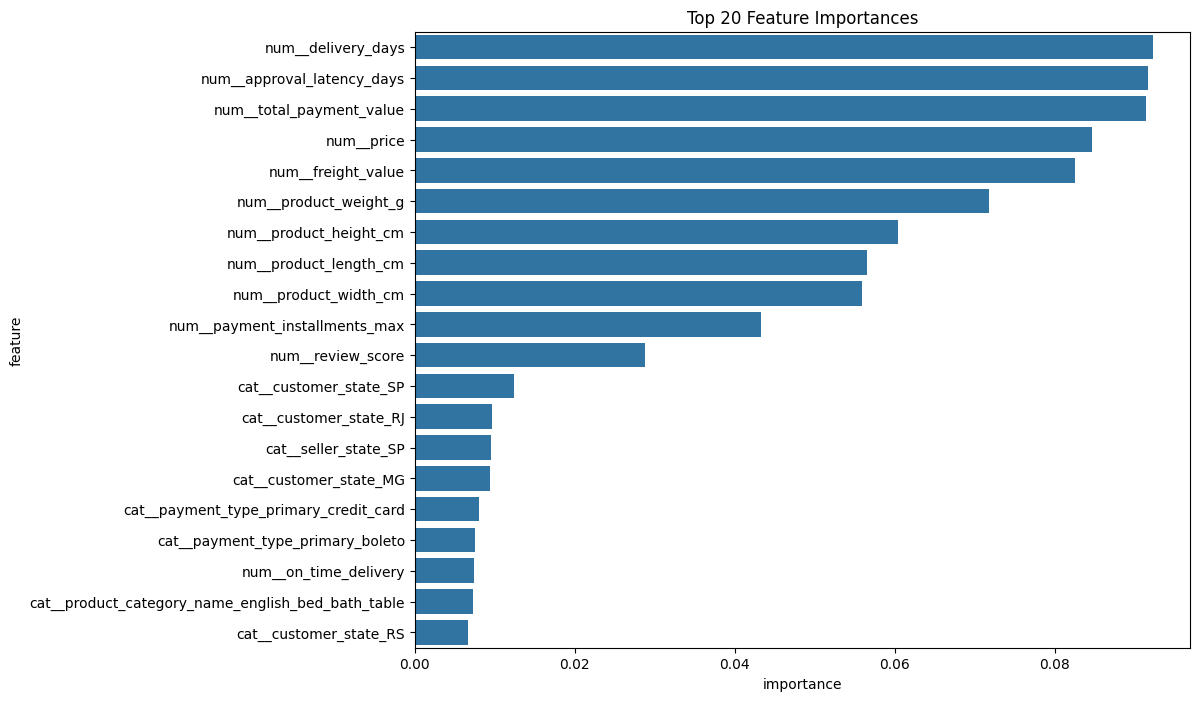

In [29]:
top20 = feature_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(data=top20,x="importance",y="feature")

plt.title("Top 20 Feature Importances")

plt.show()

## Feature Importance Analysis

Random Forest feature importance was used to identify the strongest predictors of repeat customer behavior.

### Top Predictors

| Feature | Importance |
|----------|----------:|
| Delivery Days | 0.092 |
| Approval Latency Days | 0.092 |
| Total Payment Value | 0.091 |
| Price | 0.085 |
| Freight Value | 0.082 |

### Key Findings

#### Delivery Experience Drives Retention

Delivery-related variables emerged as the strongest predictors of repeat purchasing behavior.

This suggests that customers experiencing faster order processing and shorter delivery times are more likely to return and make additional purchases.

#### Spending Behavior Matters

Transaction value variables such as price and payment value were also highly predictive.

Customers with larger purchases appear more likely to become repeat customers.

#### Product Characteristics Influence Loyalty

Product size and weight variables contributed meaningfully to prediction performance, potentially reflecting differences in product categories and customer purchasing patterns.

#### Review Scores Are Less Important Than Expected

Although review score contributes to prediction performance, its importance is substantially lower than delivery and spending-related variables.

This indicates that operational performance may have a stronger influence on customer retention than customer satisfaction scores alone.

### Business Implications

The results suggest that improving fulfillment speed and delivery performance may have a greater impact on customer retention than focusing exclusively on review score improvements.

Investments in logistics and order processing efficiency could therefore generate both customer satisfaction benefits and increased repeat purchasing behavior.

#  Model Explainability Using SHAP

Machine learning models can achieve strong predictive performance but often operate as black boxes.

SHAP (SHapley Additive exPlanations) provides insight into how individual features contribute to model predictions.

This analysis helps answer:

- Why does the model predict repeat customers?
- Which features increase repeat purchase probability?
- Which features decrease repeat purchase probability?

Understanding these drivers enables business teams to design targeted retention strategies.

In [30]:
import shap

X_train_transformed = (rf_model.named_steps["preprocessor"].transform(X_train))

X_test_transformed = ( rf_model.named_steps["preprocessor"].transform(X_test))

feature_names = (rf_model.named_steps["preprocessor"].get_feature_names_out())

In [31]:
explainer = shap.TreeExplainer( rf_model.named_steps["classifier"])

In [ ]:
sample_size = 200

X_sample = (
    X_test_transformed[:sample_size]
    .toarray()
    .astype(np.float32)
)

shap_values = explainer.shap_values(X_sample)